In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


In [2]:
df = pd.read_json('dlhe1_drsc_results.jsonl', lines=True)
df_study = pd.read_csv('top_100_nc2424_ns.tsv', sep='\t')
name_id = pd.read_csv('all_cit_top_100_eid.tsv', sep='\t')

name_id = name_id[['authfull', 'inst_name', 'scopus_id']]

df = df.merge(name_id, left_on='au_id', right_on='scopus_id')
df = df.merge(df_study, on='authfull')

In [3]:
df['fields_winner'] = False

df.loc[df['authfull'] == 'Tao, Terence Chi Shen', 'fields_winner'] = True
df.loc[df['authfull'] == 'Lions, Pierre Louis', 'fields_winner'] = True
df.loc[df['authfull'] == 'Yau, Shingtung', 'fields_winner'] = True

In [4]:
df = df[df['lastyr'] > 2020]

In [5]:
df

,au_id,p,total_drs,citing_count,lookup,audit,authfull,inst_name_x,scopus_id,inst_name_y,...,sm-subfield-1,sm-subfield-1-frac,sm-subfield-2,sm-subfield-2-frac,sm-field,sm-field-frac,rank sm-subfield-1,rank sm-subfield-1 (ns),sm-subfield-1 count,fields_winner
0,26321030600,1,1625.258688,5022,{'venues': {'23669': 'Advances in Neural Infor...,"[{'eid': '2-s2.0-105000462735', 'date': '2024-...","Bowden, Jack M.",University of Exeter,26321030600,University of Exeter,...,Statistics & Probability,0.335938,Epidemiology,0.148438,Mathematics & Statistics,0.335938,20,20,23594,False
1,7005872966,1,1314.422806,5477,{'venues': {'21100828949': 'Studies in Systems...,"[{'eid': '2-s2.0-105000268008', 'date': '2024-...","Baleanu, Dumitru I.",Lebanese American University,7005872966,Lebanese American University,...,Applied Mathematics,0.240435,Nuclear & Particle Physics,0.105217,Mathematics & Statistics,0.394783,6,6,22433,False
2,7401744122,1,3618.608230,5766,{'venues': {'21101283119': 'NLP+CSS 2024 - 6th...,"[{'eid': '2-s2.0-105000104996', 'date': '2024-...","Koch, Gary G.",UNC Gillings School of Global Public Health,7401744122,UNC Gillings School of Global Public Health,...,Statistics & Probability,0.362105,Cardiovascular System & Hematology,0.113684,Mathematics & Statistics,0.393684,159,152,23594,False
3,7006144847,1,1725.106043,3556,{'venues': {'23669': 'Advances in Neural Infor...,"[{'eid': '2-s2.0-105000464052', 'date': '2024-...","Donoho, David L.",Stanford University,7006144847,Stanford University,...,Networking & Telecommunications,0.251208,Statistics & Probability,0.140097,Mathematics & Statistics,0.362319,2,2,217319,False
4,7202122336,1,585.074016,1605,{'venues': {'21101108604': 'Chinese Quarterly ...,"[{'eid': '2-s2.0-105000065832', 'date': '2024-...","Shu, Chi Wang",Brown University,7202122336,Brown University,...,Numerical & Computational Mathematics,0.375242,Applied Mathematics,0.369439,Mathematics & Statistics,0.812379,2,2,16972,False
5,7004333790,1,2168.677138,3179,{'venues': {'10300153374': 'WSEAS Transactions...,"[{'eid': '2-s2.0-105000357069', 'date': '2024-...","Rousseeuw, Peter J.",KU Leuven,7004333790,KU Leuven,...,Statistics & Probability,0.576923,Analytical Chemistry,0.064103,Mathematics & Statistics,0.666667,10,11,23594,False
6,15056385100,1,782.271439,2506,{'venues': {'21101284636': '2024 6th Internati...,"[{'eid': '2-s2.0-105001051076', 'date': '2024-...","Kumam, Poom",King Mongkut's University of Technology Thonburi,15056385100,King Mongkut's University of Technology Thonburi,...,Applied Mathematics,0.257926,General Mathematics,0.223650,Mathematics & Statistics,0.577549,51,56,22433,False
7,9839077200,1,795.034442,2351,{'venues': {'23669': 'Advances in Neural Infor...,"[{'eid': '2-s2.0-105000475005', 'date': '2024-...","Chu, Yuming",Huzhou University,9839077200,Huzhou University,...,General Mathematics,0.319486,Applied Mathematics,0.159248,Mathematics & Statistics,0.550940,41,46,72185,False
8,57213574555,1,1413.314740,2739,{'venues': {'23669': 'Advances in Neural Infor...,"[{'eid': '2-s2.0-105000461191', 'date': '2024-...","Speed, Terence P.",University of Melbourne,57213574555,University of Melbourne,...,Bioinformatics,0.137681,Statistics & Probability,0.125604,Mathematics & Statistics,0.318841,82,78,23358,False
9,7006914313,1,1339.067474,2054,{'venues': {'21101283068': 'Proceedings - 2024...,"[{'eid': '2-s2.0-105000193241', 'date': '2024-...","Hyndman, Rob J.",Monash University,7006914313,Monash University,...,Statistics & Probability,0.297143,Econometrics,0.188571,Mathematics & Statistics,0.308571,27,27,23594,False


In [6]:
# 1. Expand the 'audit' list so each dictionary has its own row
df_exploded = df.explode('audit')

# 2. Extract dictionary keys into separate columns
# We reset the index to keep au_id aligned
df_audit = pd.json_normalize(df_exploded['audit']).set_index(df_exploded.index)

# 3. Combine with the original au_id
result = pd.concat([df_exploded['au_id'], df_audit], axis=1)

# 4. Create the 0-based index 'i' for each au_id group
result['i'] = result.groupby('au_id').cumcount()

# 5. Calculate the 'agg_score' (cumulative sum within each au_id)
result['agg_score'] = result.groupby('au_id')['score'].cumsum()

final_df = result[['au_id', 'i', 'r', 'score', 'agg_score']].copy()

final_df['au_id_str'] = final_df['au_id'].astype(str)

final_df = final_df.merge(name_id, how='left', left_on='au_id', right_on='scopus_id')

In [7]:
final_df

,au_id,i,r,score,agg_score,au_id_str,authfull,inst_name,scopus_id
0,26321030600,0,0,1.000000,1.000000,26321030600,"Bowden, Jack M.",University of Exeter,26321030600
1,26321030600,1,1,0.500000,1.500000,26321030600,"Bowden, Jack M.",University of Exeter,26321030600
2,26321030600,2,2,0.333333,1.833333,26321030600,"Bowden, Jack M.",University of Exeter,26321030600
3,26321030600,3,3,0.250000,2.083333,26321030600,"Bowden, Jack M.",University of Exeter,26321030600
4,26321030600,4,4,0.200000,2.283333,26321030600,"Bowden, Jack M.",University of Exeter,26321030600
...,...,...,...,...,...,...,...,...,...
53407,57200264409,1072,1,0.500000,421.775901,57200264409,"Balakrishnan, Narayanaswamy","McMaster University, Faculty of Science",57200264409
53408,57200264409,1073,1,0.500000,422.275901,57200264409,"Balakrishnan, Narayanaswamy","McMaster University, Faculty of Science",57200264409
53409,57200264409,1074,1,0.500000,422.775901,57200264409,"Balakrishnan, Narayanaswamy","McMaster University, Faculty of Science",57200264409
53410,57200264409,1075,51,0.019231,422.795131,57200264409,"Balakrishnan, Narayanaswamy","McMaster University, Faculty of Science",57200264409


/tmp/ipykernel_17423/1342631414.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(final_df['au_id_str'].unique()))


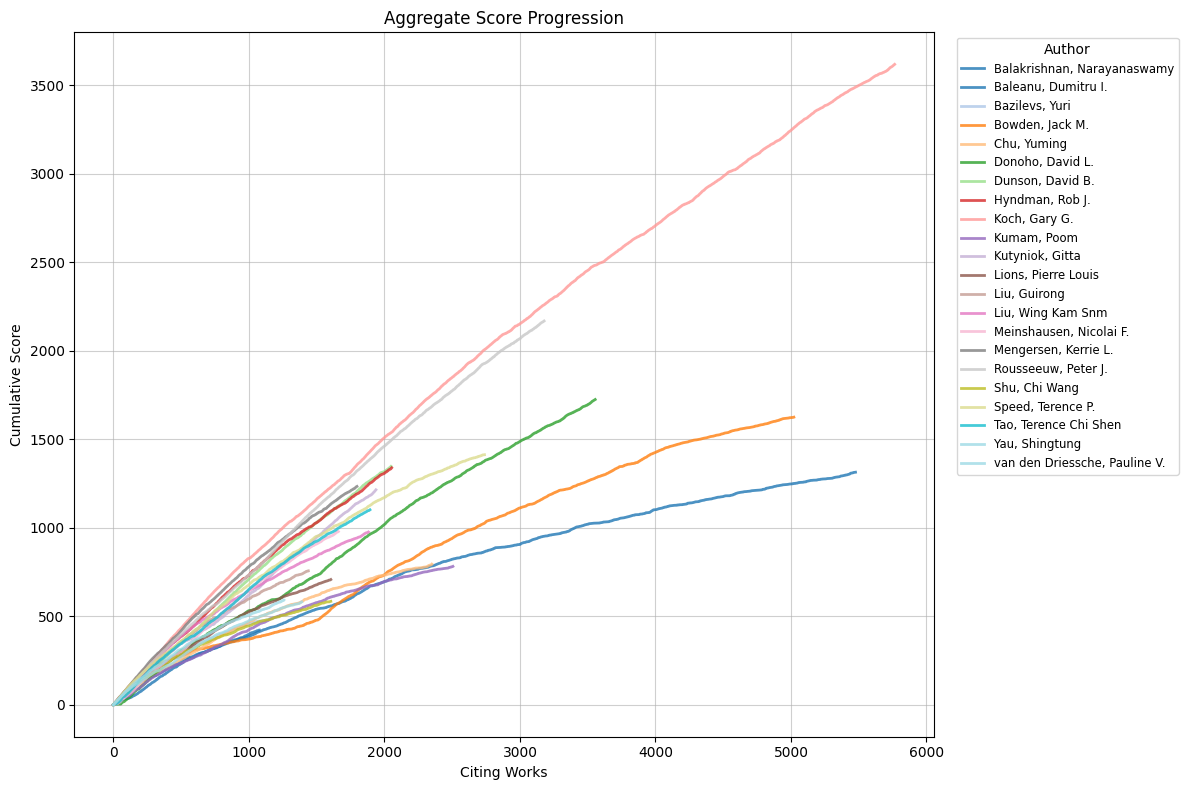

In [8]:
plt.figure(figsize=(12, 8))

colors = plt.cm.get_cmap('tab20', len(final_df['au_id_str'].unique()))

for idx, (au_id, group) in enumerate(final_df.groupby('authfull')):
    plt.plot(
        group['i'],
        group['agg_score'],
        label=au_id,
        color=colors(idx),
        linewidth=2,
        alpha=0.8
    )

plt.title('Aggregate Score Progression')
plt.xlabel('Citing Works')
plt.ylabel('Cumulative Score')

plt.legend(title='Author', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small', ncol=1)

plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

In [9]:
df.columns

Index(['au_id', 'p', 'total_drs', 'citing_count', 'lookup', 'audit',
       'authfull', 'inst_name_x', 'scopus_id', 'inst_name_y', 'cntry',
       'np6024', 'firstyr', 'lastyr', 'rank (ns)', 'nc2424 (ns)', 'h24 (ns)',
       'hm24 (ns)', 'nps (ns)', 'ncs (ns)', 'cpsf (ns)', 'ncsf (ns)',
       'npsfl (ns)', 'ncsfl (ns)', 'c (ns)', 'npciting (ns)', 'cprat (ns)',
       'np6024 cited2424 (ns)', 'self%', 'rank', 'nc2424', 'h24', 'hm24',
       'nps', 'ncs', 'cpsf', 'ncsf', 'npsfl', 'ncsfl', 'c', 'npciting',
       'cprat', 'np6024 cited2424', 'np6024_rw', 'nc2424_to_rw', 'nc2424_rw',
       'sm-subfield-1', 'sm-subfield-1-frac', 'sm-subfield-2',
       'sm-subfield-2-frac', 'sm-field', 'sm-field-frac', 'rank sm-subfield-1',
       'rank sm-subfield-1 (ns)', 'sm-subfield-1 count', 'fields_winner'],
      dtype='object')

In [10]:
selected_df = df[['authfull', 'fields_winner', 'total_drs', 'nc2424', 'npciting', 'np6024', 'h24', 'hm24', 'self%']].copy()

In [11]:
print(selected_df.to_latex(float_format="%.2f", index=False))

\begin{tabular}{lrrrrrrrr}
\toprule
authfull & fields_winner & total_drs & nc2424 & npciting & np6024 & h24 & hm24 & self% \\
\midrule
Bowden, Jack M. & False & 1625.26 & 11304 & 5032 & 128 & 29 & 9.11 & 0.02 \\
Baleanu, Dumitru I. & False & 1314.42 & 10146 & 5645 & 2300 & 31 & 20.92 & 0.16 \\
Koch, Gary G. & False & 3618.61 & 5956 & 5829 & 475 & 16 & 6.02 & 0.01 \\
Donoho, David L. & False & 1725.11 & 4568 & 3528 & 207 & 26 & 16.95 & 0.01 \\
Shu, Chi Wang & False & 585.07 & 4235 & 1587 & 517 & 26 & 18.42 & 0.09 \\
Rousseeuw, Peter J. & False & 2168.68 & 3633 & 3182 & 156 & 17 & 10.92 & 0.01 \\
Kumam, Poom & False & 782.27 & 4138 & 2637 & 1167 & 22 & 13.36 & 0.19 \\
Chu, Yuming & False & 795.03 & 3744 & 2473 & 1011 & 23 & 11.88 & 0.15 \\
Speed, Terence P. & False & 1413.31 & 3025 & 2750 & 414 & 21 & 8.00 & 0.04 \\
Hyndman, Rob J. & False & 1339.07 & 2761 & 2067 & 175 & 24 & 15.47 & 0.04 \\
Tao, Terence Chi Shen & True & 1102.18 & 2535 & 1875 & 323 & 17 & 12.77 & 0.02 \\
Lions, Pierre L

Correlation DRSC vs Total Cites (nc2424): 0.403
Correlation DRSC vs Distinct Citing Papers (npciting): 0.765


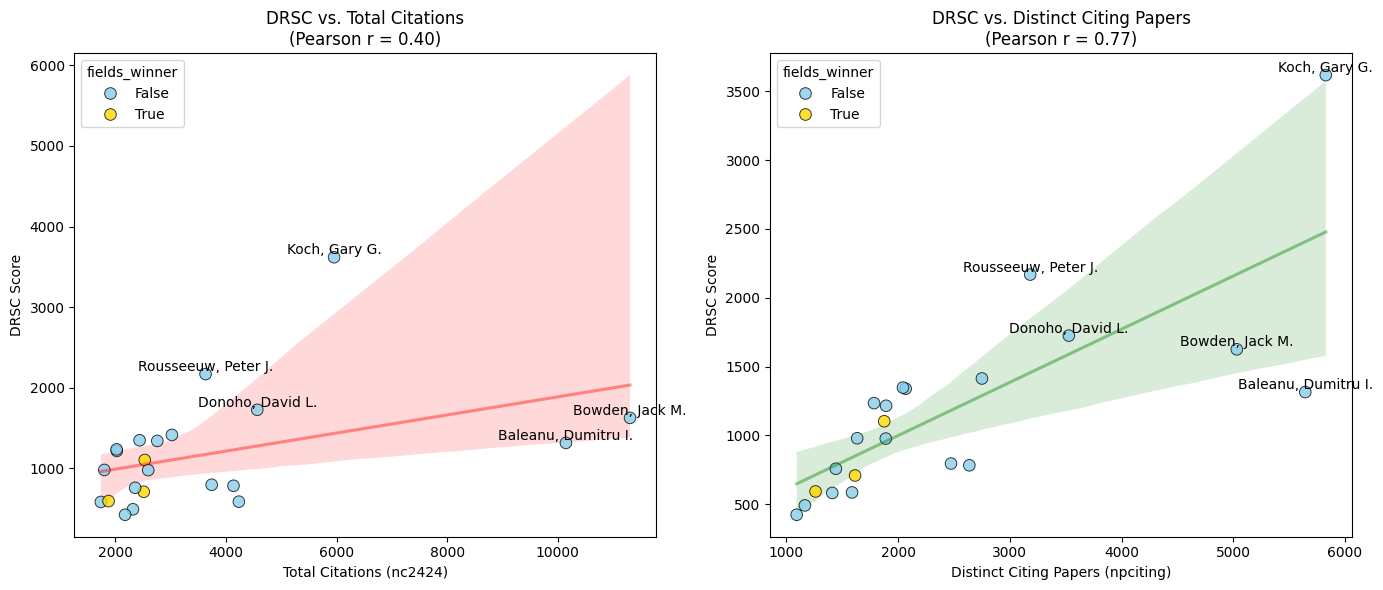

In [12]:
corr_nc, _ = pearsonr(df['total_drs'], df['nc2424'])
corr_np, _ = pearsonr(df['total_drs'], df['npciting'])

print(f"Correlation DRSC vs Total Cites (nc2424): {corr_nc:.3f}")
print(f"Correlation DRSC vs Distinct Citing Papers (npciting): {corr_np:.3f}")

plt.figure(figsize=(14, 6))

# Plot 1: DRSC vs Total Citations
plt.subplot(1, 2, 1)
sns.regplot(x='nc2424', y='total_drs', data=df, scatter=False, line_kws={'color':'red', 'alpha': 0.4})
sns.scatterplot(x='nc2424', y='total_drs', hue='fields_winner', data=df, s=70, palette={True: 'gold', False: 'skyblue'}, edgecolor='black', alpha=0.8)

plt.title(f'DRSC vs. Total Citations\n(Pearson r = {corr_nc:.2f})')
plt.xlabel('Total Citations (nc2424)')
plt.ylabel('DRSC Score')

DRS_OUTLIER_LIMIT = 2000
NC_OUTLIER_LIMIT = 4400
NP_OUTLIER_LIMIT = 2800

outliers_plot1 = df[(df['total_drs'] > DRS_OUTLIER_LIMIT) | (df['nc2424'] > NC_OUTLIER_LIMIT)]
outliers_plot2 = df[(df['total_drs'] > DRS_OUTLIER_LIMIT) | (df['npciting'] > NP_OUTLIER_LIMIT)]

for idx, row in outliers_plot1.iterrows():
    label = row.get('authfull')
    plt.text(
        x=row['nc2424'],
        y=row['total_drs'],
        s=label,
        ha='center',
        va='bottom'
    )

# Plot 2: DRSC vs Distinct Citing Papers
plt.subplot(1, 2, 2)
sns.regplot(x='npciting', y='total_drs', data=df, scatter=False, line_kws={'color':'green', 'alpha': 0.4})
sns.scatterplot(x='npciting', y='total_drs', hue='fields_winner', data=df, s=70, palette={True: 'gold', False: 'skyblue'}, edgecolor='black', alpha=0.8)
plt.title(f'DRSC vs. Distinct Citing Papers\n(Pearson r = {corr_np:.2f})')
plt.xlabel('Distinct Citing Papers (npciting)')
plt.ylabel('DRSC Score')

for idx, row in outliers_plot2.iterrows():
    label = row.get('authfull')
    plt.text(
        x=row['npciting'],
        y=row['total_drs'],
        s=label,
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Correlation DRSC vs h-index (h24): -0.028
Correlation DRSC vs hm-index (hm24): -0.322


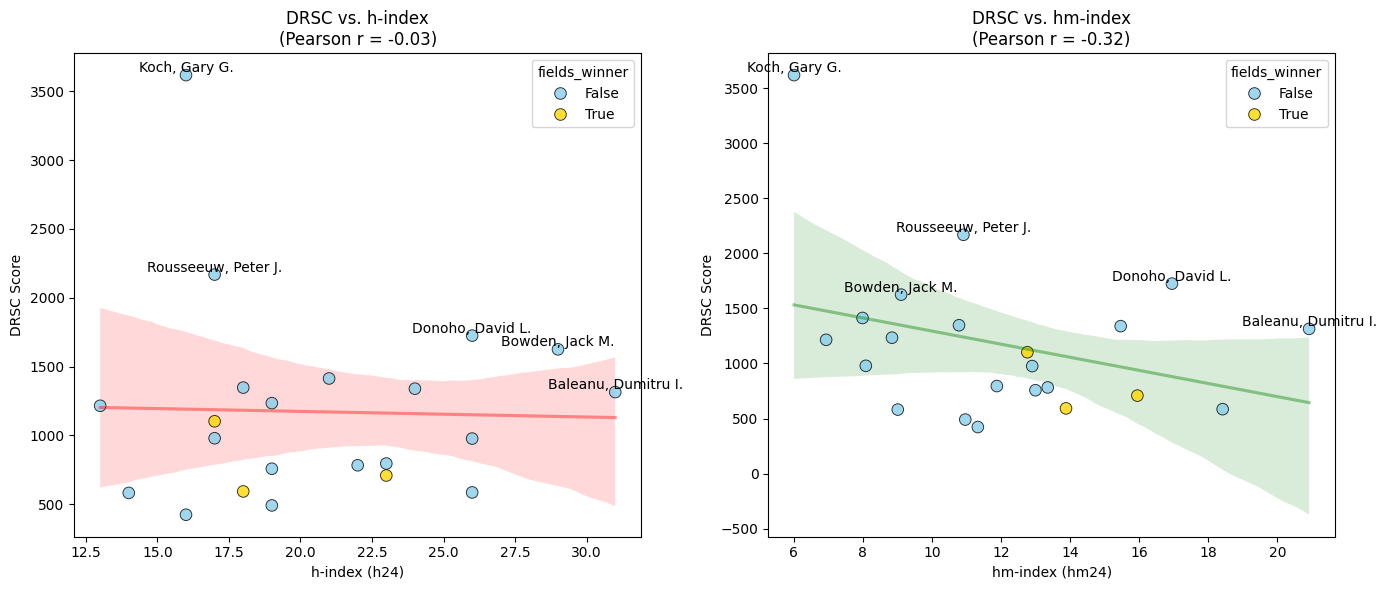

In [13]:
DRS_OUTLIER_LIMIT = 1600
H24_OUTLIER_LIMIT = 30
HM24_OUTLIER_LIMIT = 20

outliers_plot1 = df[(df['total_drs'] > DRS_OUTLIER_LIMIT) | (df['h24'] > H24_OUTLIER_LIMIT)]
outliers_plot2 = df[(df['total_drs'] > DRS_OUTLIER_LIMIT) | (df['hm24'] > HM24_OUTLIER_LIMIT)]

corr_h, _ = pearsonr(df['total_drs'], df['h24'])
corr_hm, _ = pearsonr(df['total_drs'], df['hm24'])

print(f"Correlation DRSC vs h-index (h24): {corr_h:.3f}")
print(f"Correlation DRSC vs hm-index (hm24): {corr_hm:.3f}")

plt.figure(figsize=(14, 6))

# Plot 1: DRSC vs h-index
plt.subplot(1, 2, 1)
sns.regplot(x='h24', y='total_drs', data=df, scatter=False, line_kws={'color':'red', 'alpha': 0.4})
sns.scatterplot(x='h24', y='total_drs', hue='fields_winner', data=df, s=70, palette={True: 'gold', False: 'skyblue'}, edgecolor='black', alpha=0.8)

for idx, row in outliers_plot1.iterrows():
    label = row.get('authfull')
    plt.text(
        x=row['h24'],
        y=row['total_drs'],
        s=label,
        ha='center',
        va='bottom'
    )

plt.title(f'DRSC vs. h-index\n(Pearson r = {corr_h:.2f})')
plt.xlabel('h-index (h24)')
plt.ylabel('DRSC Score')

# Plot 2: DRSC vs hm-index
plt.subplot(1, 2, 2)
sns.regplot(x='hm24', y='total_drs', data=df, scatter=False, line_kws={'color':'green', 'alpha': 0.4})
sns.scatterplot(x='hm24', y='total_drs', hue='fields_winner', data=df, s=70, palette={True: 'gold', False: 'skyblue'}, edgecolor='black', alpha=0.8)

for idx, row in outliers_plot2.iterrows():
    label = row.get('authfull')
    plt.text(
        x=row['hm24'],
        y=row['total_drs'],
        s=label,
        ha='center',
        va='bottom'
    )

plt.title(f'DRSC vs. hm-index\n(Pearson r = {corr_hm:.2f})')
plt.xlabel('hm-index (hm24)')
plt.ylabel('DRSC Score')

plt.tight_layout()
plt.show()


DRSC vs. Self%: -0.472
Self% vs Ratio: -0.594


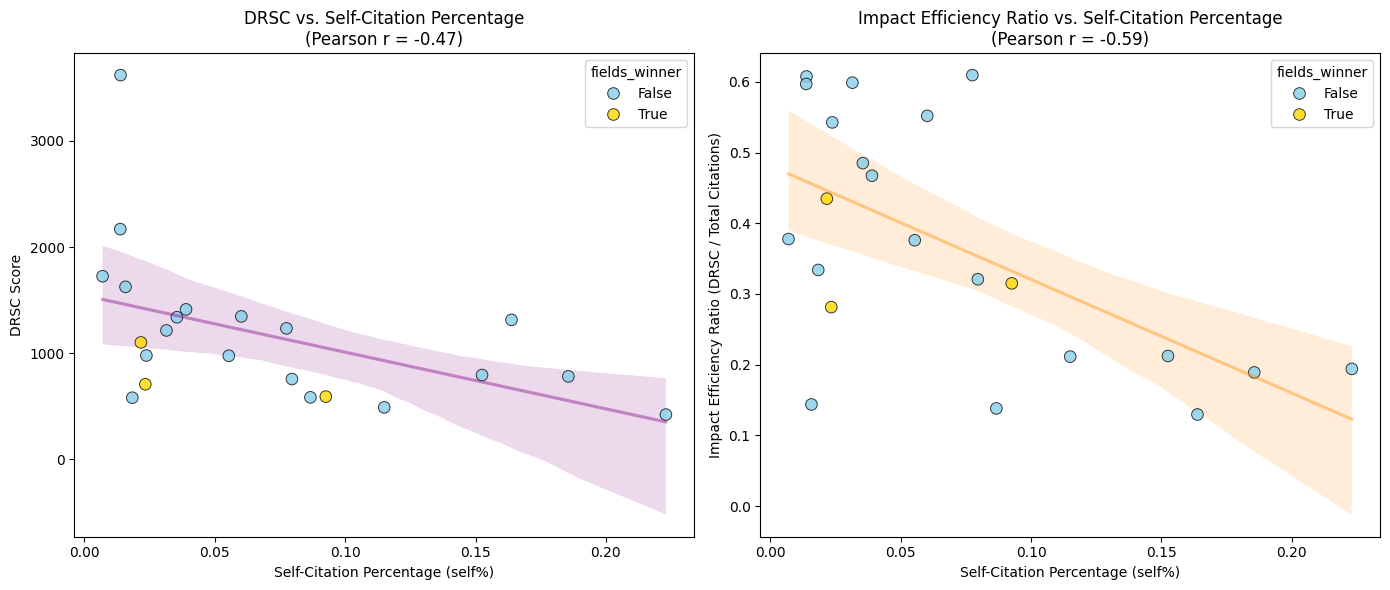

In [14]:
df['ratio'] = df['total_drs'] / df['nc2424']


corr_left, _ = pearsonr(df['self%'], df['total_drs'])
corr_right, _ = pearsonr(df['self%'], df['ratio'])

print(f"DRSC vs. Self%: {corr_left:.3f}")
print(f"Self% vs Ratio: {corr_right:.3f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.regplot(x='self%', y='total_drs', data=df, scatter=False, line_kws={'color':'purple', 'alpha': 0.4})
sns.scatterplot(x='self%', y='total_drs', hue='fields_winner', data=df, s=70,
                palette={True: 'gold', False: 'skyblue'}, edgecolor='black', alpha=0.8)


plt.title(f'DRSC vs. Self-Citation Percentage\n(Pearson r = {corr_left:.2f})')
plt.xlabel('Self-Citation Percentage (self%)')
plt.ylabel('DRSC Score')

plt.subplot(1, 2, 2)
sns.regplot(x='self%', y='ratio', data=df, scatter=False, line_kws={'color':'darkorange', 'alpha': 0.4})
sns.scatterplot(x='self%', y='ratio', hue='fields_winner', data=df, s=70,
                palette={True: 'gold', False: 'skyblue'}, edgecolor='black', alpha=0.8)



plt.title(f'Impact Efficiency Ratio vs. Self-Citation Percentage\n(Pearson r = {corr_right:.2f})')
plt.xlabel('Self-Citation Percentage (self%)')
plt.ylabel('Impact Efficiency Ratio (DRSC / Total Citations)')

plt.tight_layout()
plt.show()